# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

We could use the nfcore/differentialabundance pipeline. This pipeline can support rnaseq output and generates statistics about differential abundance.

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [ ]:
# Create samplesheet:
import pandas as pd

# Read the count matrix
counts = pd.read_csv("data/salmon.merged.gene_counts.tsv", sep="\t")

# Extract sample names (excluding gene annotation columns)
samples = counts.columns.drop(["gene_id", "gene_name"])

# Create the samplesheet
samplesheet = pd.DataFrame({"sample": samples})

# Remove replicate numbers to obtain the experimental condition
samplesheet["Condition"] = samplesheet["sample"].str.replace(
    r"_\d+$", "", regex=True
)

# Save without the pandas index
samplesheet.to_csv("samplesheet.csv", index=False)

# Display the result
print(samplesheet)

        sample Condition
0   Sham_oxy_1  Sham_oxy
1   Sham_oxy_2  Sham_oxy
2   Sham_oxy_3  Sham_oxy
3   Sham_oxy_4  Sham_oxy
4   Sham_Sal_1  Sham_Sal
5   Sham_Sal_2  Sham_Sal
6   Sham_Sal_3  Sham_Sal
7   Sham_Sal_4  Sham_Sal
8    SNI_oxy_1   SNI_oxy
9    SNI_oxy_2   SNI_oxy
10   SNI_oxy_3   SNI_oxy
11   SNI_oxy_4   SNI_oxy
12   SNI_Sal_1   SNI_Sal
13   SNI_Sal_2   SNI_Sal
14   SNI_Sal_3   SNI_Sal
15   SNI_Sal_4   SNI_Sal


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [4]:
nextflow run nf-core/differentialabundance \
  -r 2.0.0 \
  --study_name mouse_oxycodone \
  --study_type rnaseq \
  -profile rnaseq,docker \
  -c ../memory_issue.config \
  --input samplesheet.csv \
  --matrix data/salmon.merged.gene_counts.tsv \
  --features data/features.tsv \
  --features_metadata_cols gene_id,gene_name \
  --contrasts data/contrasts.csv \
  --feature_length_matrix data/salmon.merged.gene_lengths.renamed.tsv \
  --outdir results


SyntaxError: invalid syntax (2393654609.py, line 1)

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

Parameters:
 nextflow run nf-core/differentialabundance: specifies the pipeline we want to use
  -r 2.0.0: pipeline version
  --study_name mouse_oxycodone: A string identifier used to name result files in the output directory
  --study_type rnaseq: Input data format category used for input validation and routing (not for selecting analysis methods).
  -profile rnaseq,docker: rnaseq profile because we want to perform differential gene expression analysis on RNA-seq data using DESeq2; docker profile to run the pipeline in a reproducible environment
  --input samplesheet.csv: we created this ourself, it inludes a column for the sample names and one for conditions
  --matrix data/salmon.merged.gene_counts.tsv: gene-count matrix containing estimated counts for the 16 samples
  --features data/features.tsv: we created our own feature annotation table,this is linking Ensembl gene identifiers to gene symbols.
                                Created with: cut -f1,2 data/salmon.merged.gene_counts.tsv > data/features.tsv
  --features_metadata_cols gene_id,gene_name: Comma-separated string, specifies feature metadata columns to be used for exploratory analysis, platform-specific (Specifies the annotation columns we intend to retain from the feature table)
  --contrasts data/contrasts.csv: Defines which experimental groups should be compared.
  --feature_length_matrix data/salmon.merged.gene_lengths.renamed.tsv: Provides gene-length estimates corresponding to each gene and sample for normalization. (used to provide transcript/gene lengths to DESeq2 to model length bias across samples) (Needed to match the column names here first!)

What were the outputs of the pipeline?

We get multiple folders and files including pipeline_info (contains information about the execution and parameters), different plots and an html report including a exploratory analysis and a differential analysis. 

The exploratory analysis inludes PCA and Scree plots as well as a clustering heatmap and outlier detection. We could use this for example in the next step to check if we want to exclude any samples.

The differential analysis includes a differential gene count table, Upset plot and volcano and boxplots as well as a differential gene table (contain log2 fold changes and adjusted p-values) for each contrast we specified in the contrasts file.

In [ ]:
#!TODO

Would you exclude any samples? If yes, which and why?

So our report tells us in the outlier detection:"No outlying samples were detected in groups defined by Condition." ,but I think there are some samples we could potantialy exclude anyway. 
For example in the PCA plot the samples SNI_Sal_4 and SNI_Sal_2 seem to be separated from the other samples and also in the expression distribution plots they show unusual distributions compared to the other samples. Also in the dendrogram of the clustering heatmap they form an outgroup. This suggests that they may differ substantially from their biological replicates and could influence the differential expression analysis. Thus I would suggest to exclude them.

Additionally, Sham_oxy_1 shows a relatively large deviation from the average in the MAD plot this could also be a candidate to exclude.

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

No the results differ extremly from the reported ones in the Paper! Instead of a couple hundrred or thousand only 7 or 17 genes were differentially expressed, thus we could not confirm the results with our pipeline.

Comparisons:
Our Report:
1. Sham_oxy versus Sham_Sal in Condition 7 (up) 0 (down)
2. SNI_oxy versus SNI_Sal in Condition   0 (up) 17 (down)

Paper:
1. The Sham-Oxy condition altered 2,609 genes in the NAc as compared to Sham-Sal controls.
2. According to figure 4a there are 522 differentially expressed genes for SNI-oxy vs SNI_sal in the NAc.

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

NAc (Nucleus accumbens): 
Brain region is involved in reward, motivation and addiction. It receives dopaminergic input from the VTA.

VTA (Ventral tegmental area): 
A region in the midbrain containing dopamine-producing neurons. It plays an important role in reward processing, motivation and addiction.

mPFC (Medial prefrontal cortex): 
This region is involved in executive functions, decision-making and memory. It also contributes to reward processing and addiction.


Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

No, they dont provide a gene list for each brain region.

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

No, only a list of differentially expressed genes does not give us information about their biological functions and the molecular mechanisms involved. 

The publication states that they performed additional analysis for this:
"To better understand the molecular signature of DEGs affected by oxycodone withdrawal under SNI versus sham conditions, we performed Gene Ontology (GO) analysis for enriched biological processes and ingenuity pathway analysis (IPA)."

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

change contrast sheet and run pipeline again:

contrasts2:
id,variable,reference,target
injury_effect,Condition,Sham_Sal,SNI_Sal
oxycodone_effect,Condition,Sham_Sal,Sham_oxy
combined_effect,Condition,Sham_Sal,SNI_oxy

nextflow run nf-core/differentialabundance \
  -r 2.0.0 \
  --study_name mouse_oxycodone2 \
  --study_type rnaseq \
  -profile rnaseq,docker \
  -c ../memory_issue.config \
  --input samplesheet.csv \
  --matrix data/salmon.merged.gene_counts.tsv \
  --features data/features.tsv \
  --features_metadata_cols gene_id,gene_name \
  --contrasts contrasts2.csv \
  --feature_length_matrix data/salmon.merged.gene_lengths.renamed.tsv \
  --outdir results2

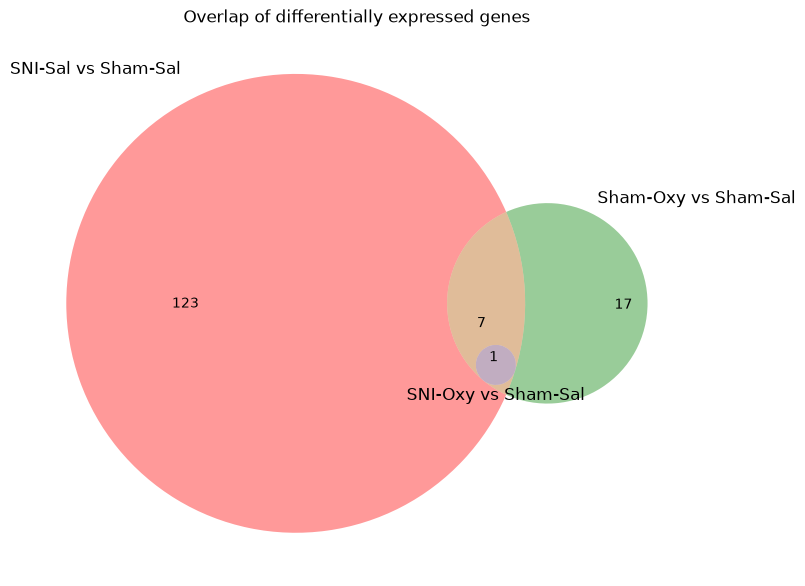

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Directory containing the DESeq2 results
path = "results2/tables/differential/rnaseq/"

# Load the three comparisons
# injury_effect,Condition,Sham_Sal,SNI_Sal
injury = pd.read_csv(
    path + "injury_effect_mouse_oxycodone2.deseq2.results.tsv",
    sep="\t"
)

# oxycodone_effect,Condition,Sham_Sal,Sham_oxy
oxycodone = pd.read_csv(
    path + "oxycodone_effect_mouse_oxycodone2.deseq2.results.tsv",
    sep="\t"
)

# combined_effect,Condition,Sham_Sal,SNI_oxy
combined = pd.read_csv(
    path + "combined_effect_mouse_oxycodone2.deseq2.results.tsv",
    sep="\t"
)

# Select differentially expressed genes using the same thresholds as in paper
def get_degs(df):
    filtered = df[
        (df["pvalue"] < 0.05) &
        (df["log2FoldChange"].abs() > 0.5)
    ]
    return set(filtered["gene_id"])

injury_genes = get_degs(injury)
oxycodone_genes = get_degs(oxycodone)
combined_genes = get_degs(combined)


# Create the Venn diagram
plt.figure(figsize=(8, 6))

venn3(
    [injury_genes, oxycodone_genes, combined_genes],
    set_labels=[
        "SNI-Sal vs Sham-Sal",
        "Sham-Oxy vs Sham-Sal",
        "SNI-Oxy vs Sham-Sal"
    ]
)

plt.title("Overlap of differentially expressed genes")
plt.tight_layout()
plt.savefig("venn_diagram_figure3.png", dpi=300)
plt.show()